# 04 — Pipeline End-to-End: Experimente C1 și C2

Rulează **pipeline-ul two-stage complet** (detector + clasificator) pe setul de test.

| ID | Detector | Clasificator | Scop |
|----|----------|--------------|------|
| C1 | A22 — yolov8n, imgsz=416 | B2 — yolov8n-cls, imgsz=224 | Baseline end-to-end |
| C2 | A3-final — yolov8s, imgsz=640 | B2 — yolov8n-cls, imgsz=224 | Model mai mare = mai bune rezultate? |

**Metrici raportate**: nr. imagini cu detecții, total detecții, distribuție materiale, viteză inferență.

In [1]:
import csv
import json
import sys
import time
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('../..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ultralytics import YOLO
from src.detect_two_stage import detect_and_classify, classifier_names

print('REPO_ROOT:', REPO_ROOT)

REPO_ROOT: D:\TrashDetectionSystem


---
## Configurare

In [2]:
# ── Experiment config ─────────────────────────────────────────────────────────
EXPERIMENTS = {
    'C1': {
        'detector_pt':   REPO_ROOT / 'runs/detect/parks-trash-A22/weights/best.pt',
        'classifier_pt': REPO_ROOT / 'runs/classify/parks-cls-B2/weights/best.pt',
        'det_imgsz': 416,
        'cls_imgsz': 224,
        'det_conf':  0.25,
        'label': 'C1 — A22 (yolov8n) + B2',
    },
    'C2': {
        'detector_pt':   REPO_ROOT / 'runs/detect/parks-trash-A3-final/weights/best.pt',
        'classifier_pt': REPO_ROOT / 'runs/classify/parks-cls-B2/weights/best.pt',
        'det_imgsz': 640,
        'cls_imgsz': 224,
        'det_conf':  0.25,
        'label': 'C2 — A3-final (yolov8s) + B2',
    },
}

TEST_DIR    = REPO_ROOT / 'datasets/parks_detect_full/images/test'
RESULTS_DIR = REPO_ROOT / 'results/pipeline'
OUTPUT_DIR  = REPO_ROOT / 'outputs/pipeline_C1_C2'
DEVICE      = '0'           # '0' = GPU | 'cpu'
IMAGE_EXTS  = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

images = sorted(p for p in TEST_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTS)
print(f'Test images: {len(images)}')
for exp_id, cfg in EXPERIMENTS.items():
    ok_det = cfg['detector_pt'].exists()
    ok_cls = cfg['classifier_pt'].exists()
    print(f'  {exp_id}: detector={ok_det}, classifier={ok_cls}')

Test images: 227
  C1: detector=True, classifier=True
  C2: detector=True, classifier=True


---
## Rulare experimente

In [3]:
def run_pipeline(exp_id, cfg, images, device):
    """Run two-stage pipeline on all test images. Returns summary dict + per-image rows."""
    detector   = YOLO(str(cfg['detector_pt']))
    classifier = YOLO(str(cfg['classifier_pt']))
    cls_names  = classifier_names(classifier)

    rows             = []
    material_counter = Counter()
    imgs_with_det    = 0
    total_time_ms    = 0.0

    for img_path in images:
        frame = cv2.imread(str(img_path))
        if frame is None:
            continue

        t0 = time.perf_counter()
        detections = detect_and_classify(
            frame, detector, classifier,
            cfg['det_conf'], cfg['det_imgsz'], cfg['cls_imgsz'], cls_names
        )
        elapsed_ms = (time.perf_counter() - t0) * 1000
        total_time_ms += elapsed_ms

        if detections:
            imgs_with_det += 1
        for d in detections:
            material_counter[d['material_name']] += 1
            l, t, r, b = d['box']
            rows.append({
                'exp':            exp_id,
                'image':          img_path.name,
                'det_score':      round(d['det_score'], 4),
                'material':       d['material_name'],
                'material_score': round(d['material_score'], 4),
                'x1': l, 'y1': t, 'x2': r, 'y2': b,
            })

    total_det   = sum(material_counter.values())
    n_images    = len(images)
    avg_time_ms = total_time_ms / n_images if n_images else 0

    summary = {
        'exp':               exp_id,
        'label':             cfg['label'],
        'detector':          str(cfg['detector_pt'].parent.parent.name),
        'classifier':        str(cfg['classifier_pt'].parent.parent.name),
        'det_imgsz':         cfg['det_imgsz'],
        'test_images':       n_images,
        'imgs_with_det':     imgs_with_det,
        'detection_rate':    round(imgs_with_det / n_images, 4) if n_images else 0,
        'total_detections':  total_det,
        'avg_det_per_img':   round(total_det / n_images, 2) if n_images else 0,
        'avg_ms_per_img':    round(avg_time_ms, 1),
        'material_dist':     dict(material_counter),
    }
    return summary, rows


all_summaries = {}
all_rows      = []

for exp_id, cfg in EXPERIMENTS.items():
    print(f'\n=== {exp_id}: {cfg["label"]} ===')
    summary, rows = run_pipeline(exp_id, cfg, images, DEVICE)
    all_summaries[exp_id] = summary
    all_rows.extend(rows)

    print(f'  Images processed : {summary["test_images"]}')
    print(f'  With detections  : {summary["imgs_with_det"]} ({summary["detection_rate"]*100:.1f}%)')
    print(f'  Total detections : {summary["total_detections"]}')
    print(f'  Avg det/image    : {summary["avg_det_per_img"]}')
    print(f'  Avg ms/image     : {summary["avg_ms_per_img"]} ms')
    print(f'  Material dist    : {summary["material_dist"]}')

print('\nDone.')


=== C1: C1 — A22 (yolov8n) + B2 ===
  Images processed : 227
  With detections  : 9 (4.0%)
  Total detections : 10
  Avg det/image    : 0.04
  Avg ms/image     : 26.3 ms
  Material dist    : {'metal': 5, 'paper': 2, 'plastic': 3}

=== C2: C2 — A3-final (yolov8s) + B2 ===
  Images processed : 227
  With detections  : 219 (96.5%)
  Total detections : 739
  Avg det/image    : 3.26
  Avg ms/image     : 74.7 ms
  Material dist    : {'metal': 267, 'plastic': 77, 'paper': 276, 'glass': 94, 'other': 25}

Done.


---
## Salvare rezultate

In [4]:
# Save per-detection CSV
csv_path = OUTPUT_DIR / 'detections_C1_C2.csv'
df = pd.DataFrame(all_rows)
df.to_csv(csv_path, index=False)
print(f'Detections CSV saved: {csv_path}  ({len(df)} rows)')

# Save JSON summaries (force-written to results/ tracked folder)
for exp_id, summary in all_summaries.items():
    out = RESULTS_DIR / f'{exp_id}-summary.json'
    with open(out, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f'Summary saved: {out}')

Detections CSV saved: D:\TrashDetectionSystem\outputs\pipeline_C1_C2\detections_C1_C2.csv  (749 rows)
Summary saved: D:\TrashDetectionSystem\results\pipeline\C1-summary.json
Summary saved: D:\TrashDetectionSystem\results\pipeline\C2-summary.json


---
## Comparație C1 vs C2

In [5]:
compare_keys = ['label', 'imgs_with_det', 'detection_rate', 'total_detections',
                'avg_det_per_img', 'avg_ms_per_img']

rows_table = []
for exp_id, s in all_summaries.items():
    row = {'Experiment': exp_id}
    row['Pipeline'] = s['label']
    row['Det imgsz'] = s['det_imgsz']
    row['Imgs w/ det'] = f"{s['imgs_with_det']}/{s['test_images']}"
    row['Det rate %'] = f"{s['detection_rate']*100:.1f}%"
    row['Total dets'] = s['total_detections']
    row['Avg det/img'] = s['avg_det_per_img']
    row['Avg ms/img'] = s['avg_ms_per_img']
    rows_table.append(row)

df_compare = pd.DataFrame(rows_table).set_index('Experiment')
print('=== C1 vs C2 Comparison ===')
print(df_compare.to_string())

=== C1 vs C2 Comparison ===
                                Pipeline  Det imgsz Imgs w/ det Det rate %  Total dets  Avg det/img  Avg ms/img
Experiment                                                                                                     
C1               C1 — A22 (yolov8n) + B2        416       9/227       4.0%          10         0.04        26.3
C2          C2 — A3-final (yolov8s) + B2        640     219/227      96.5%         739         3.26        74.7


---
## Distribuție materiale

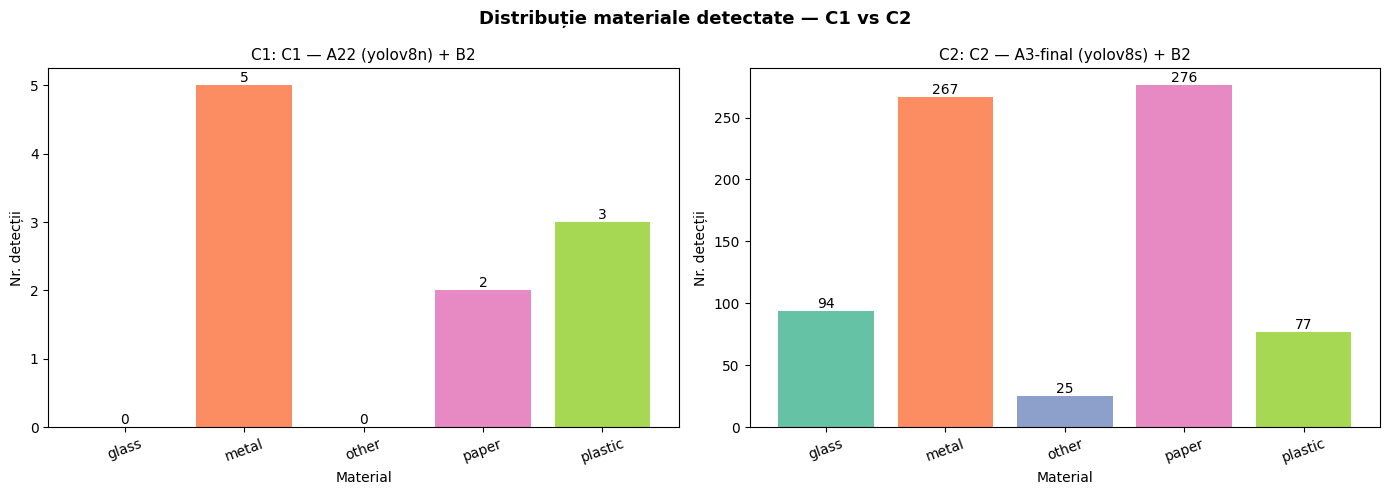

Chart saved.


In [6]:
all_materials = sorted({m for s in all_summaries.values() for m in s['material_dist']})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.Set2.colors

for ax, (exp_id, summary) in zip(axes, all_summaries.items()):
    dist = summary['material_dist']
    vals = [dist.get(m, 0) for m in all_materials]
    bars = ax.bar(all_materials, vals, color=colors[:len(all_materials)])
    ax.set_title(f'{exp_id}: {summary["label"]}', fontsize=11)
    ax.set_xlabel('Material')
    ax.set_ylabel('Nr. detecții')
    ax.bar_label(bars)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Distribuție materiale detectate — C1 vs C2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'material_dist_C1_C2.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

---
## Exemple vizuale — imagini cu cele mai multe detecții

In [ ]:

from IPython.display import Image as IPImage, display
from src.detect_two_stage import draw_detections

# Load results from already-saved CSV if available, else use in-memory df
try:
    _df = df
except NameError:
    csv_path = OUTPUT_DIR / 'detections_C1_C2.csv'
    _df = pd.read_csv(csv_path)
else:
    _df = df

# Pick C2 (better detector) and show top-5 images by detection count
if not _df.empty:
    top_images = (
        _df[_df['exp'] == 'C2']
        .groupby('image')['material'].count()
        .nlargest(5)
        .index.tolist()
    )

    cfg = EXPERIMENTS['C2']
    detector   = YOLO(str(cfg['detector_pt']))
    classifier = YOLO(str(cfg['classifier_pt']))
    cls_names  = classifier_names(classifier)
    annotated_dir = OUTPUT_DIR / 'annotated_C2'
    annotated_dir.mkdir(exist_ok=True)

    for img_name in top_images:
        img_path = TEST_DIR / img_name
        frame = cv2.imread(str(img_path))
        if frame is None:
            continue
        detections = detect_and_classify(
            frame, detector, classifier,
            cfg['det_conf'], cfg['det_imgsz'], cfg['cls_imgsz'], cls_names
        )
        annotated = draw_detections(frame.copy(), detections, fps=0.0, max_labels=5, line_width=2)
        out_path = annotated_dir / img_name
        cv2.imwrite(str(out_path), annotated)
        print(f'{img_name}: {len(detections)} detections')
        display(IPImage(filename=str(out_path), width=700))
else:
    print('No detections found — check model weights and test images.')


TypeError: draw_detections() missing 2 required positional arguments: 'max_labels' and 'line_width'